In [1]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

import seaborn as sns

from scipy import stats

from sklearn.datasets import load_diabetes

In [2]:
diabetes = load_diabetes()
diabetes_df= pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
diabetes_df['target'] = diabetes.target

In [3]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


age       0.187889
sex       0.043062
bmi       0.586450
bp        0.441482
s1        0.212022
s2        0.174054
s3       -0.394789
s4        0.430453
s5        0.565883
s6        0.382483
target    1.000000
Name: target, dtype: float64

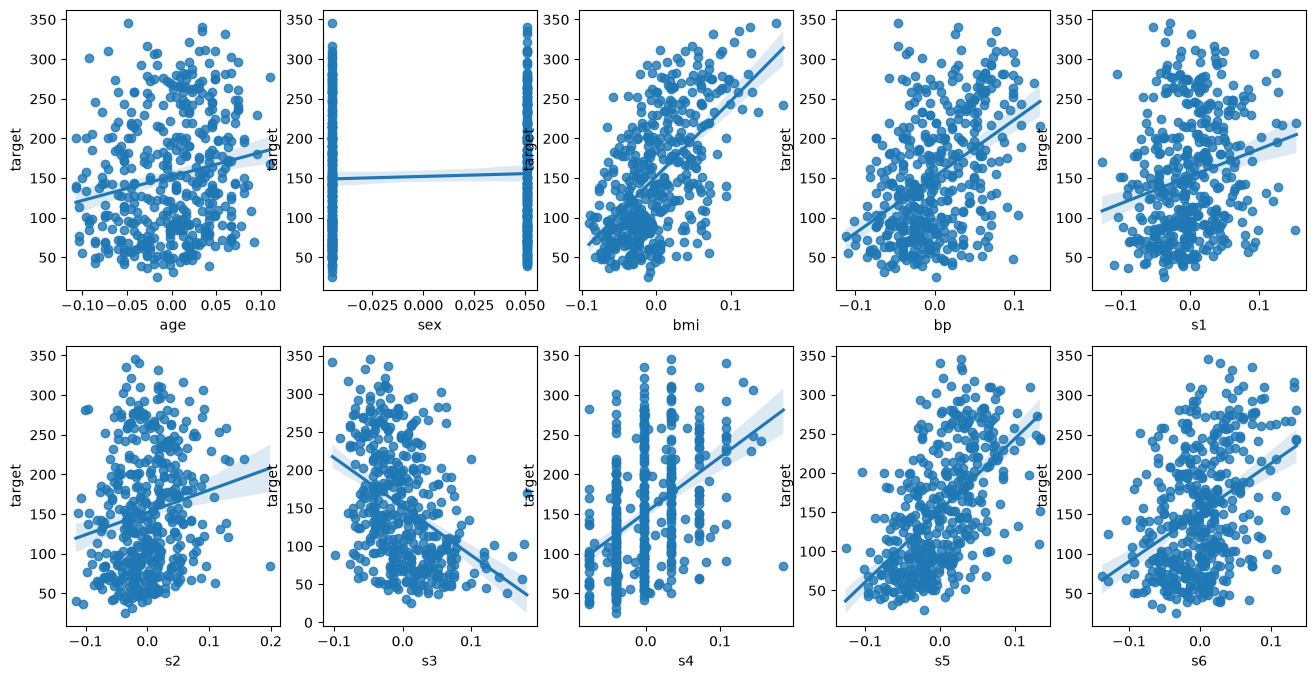

In [4]:
fig, axs= plt.subplots(figsize=(16, 8), ncols=5, nrows=2)
lm_features= ['age','sex','bmi','bp','s1','s2','s3','s4', 's5', 's6']
for i, feature in enumerate(lm_features):
    row = int(i/5)
    col = i%5
    sns.regplot(x=feature, y='target', data=diabetes_df, ax=axs[row][col])
diabetes_df.corr()['target']
# 종속변수 target과의 상관관계를 확인
# 성별은 막대그래프를 그려서 비교하는 것이 올바름

<Axes: xlabel='sex', ylabel='target'>

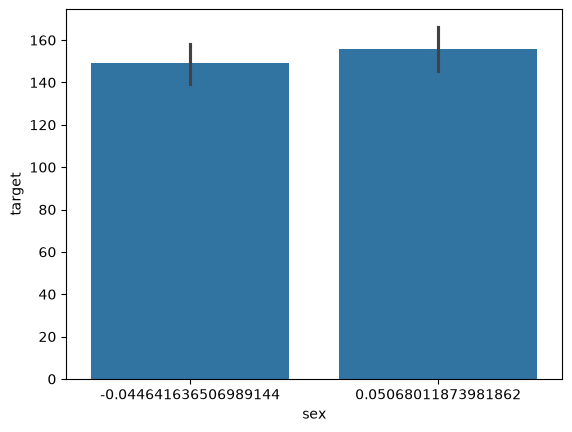

In [5]:
sns.barplot(x = 'sex', y = 'target', data = diabetes_df)

# 성별은 관계없는 변수임을 확실하게 알 수 있다.

In [6]:
# 머신러닝을 돌리기 위해 필요한 3가지
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X_train, X_test , y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=156)

In [7]:
# 위 셀의 코드를 돌리고 train_test_split이 제대로 되었는지 확인하려면
# 컬럼이 몇개인지, 몇차원인지, 트레인과 테스트의 데이터 개수 차이를 확실하게 알 수 있다.
print(X_train.shape, X_test.shape , y_train.shape, y_test.shape)

(309, 10) (133, 10) (309,) (133,)


In [8]:
lr = LinearRegression()
lr.fit(X_train ,y_train)
pred = lr.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE : {mse:.3f} , RMSE : {rmse:.3F}')
print(f'Variance score : {r2_score(y_test, pred):.3f}')

# 절대적인 점수가 중요한 것이 아님
# 다른 모델에 비해 상대적으로 좋으면 된거
# 절대평가적으로 생각하는 것이 아닌 상대평가적으로 생각하기

# RMSE는 0에 가까울수록 좋다.
# MSE와 RMSE는 루트를 씌우고 안씌우고 차이라 사실상 같은값이다.

MSE : 2993.705 , RMSE : 54.715
Variance score : 0.497


In [9]:
# 성별만 빼고 머신러닝 진행
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X = X.drop('sex', axis = 1)

X_train, X_test , y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=156)

lr = LinearRegression()
lr.fit(X_train ,y_train)
pred = lr.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE : {mse:.3f} , RMSE : {rmse:.3F}')
print(f'Variance score : {r2_score(y_test, pred):.3f}')

# 성별을 뺀 모델이 성능이 오히려 더 안좋게 나왔다.
# 다수의 원인을 가지고 하나를 예측하다보니 예측을 하는데에 있어서 연관이 생겼다는 것을 알 수 있다.

MSE : 3075.832 , RMSE : 55.460
Variance score : 0.483


In [10]:
# 다시 성별을 빼지않은 데이터로 진행

print('절편 값:', lr.intercept_)     # .intercept_는 현재 학습했을 때의 절편값을 반환
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: 152.39030230183667
회귀 계수값: [  21.3  522.6  256.1 -997.9  665.5  205.    66.6  926.    23.7]


In [11]:
lr.coef_

array([  21.27887465,  522.61226513,  256.11792967, -997.8957004 ,
        665.54455771,  204.9982838 ,   66.62459806,  925.98226963,
         23.65864671])

In [12]:
one_data = X_test.iloc[10]     # X_test에서 10번째 값
one_data

age    0.041708
bmi   -0.008362
bp    -0.026328
s1     0.024574
s2     0.016222
s3     0.070730
s4    -0.039493
s5    -0.048359
s6    -0.030072
Name: 178, dtype: float64

In [13]:
# lr.predict(one_data)  이렇게 하면 오류가 발생한다. 1차원이기 때문

one_data = X_test.iloc[[10]]    # 이렇게 2차원으로 만들어야 됨
lr.predict(one_data)

array([94.81630725])

In [14]:
sum(X_test.iloc[10] * lr.coef_) + lr.intercept_

# 위 셀의 값을 구하는 공식

np.float64(94.81630725081317)

In [15]:
coeff = pd.Series(data=np.round(lr.coef_, 1), index = X.columns )
coeff

age     21.3
bmi    522.6
bp     256.1
s1    -997.9
s2     665.5
s3     205.0
s4      66.6
s5     926.0
s6      23.7
dtype: float64

In [16]:
# cross validation score 사용
from sklearn.model_selection import cross_val_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

# 모델 불러오기
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X, y, scoring = "neg_mean_squared_error", cv = 5)
# 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'

# neg_mse_scores는 음수(neg)이자 MSE(제곱값)이므로,
# -1을 곱해 양수 MSE로 되돌린 뒤 np.sqrt로 제곱근을 씌워 RMSE로 변환한다.
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 folds의 개별 Negative MSE scores:', np.round(neg_mse_scores, 2))
print('5 folds의 개별 RMSE scores :', np.round(rmse_scores, 2))
print(f'5 folds의 평균 RMSE : {avg_rmse:.3f}')

5 folds의 개별 Negative MSE scores: [-2779.92 -3028.84 -3237.69 -3008.75 -2910.21]
5 folds의 개별 RMSE scores : [52.72 55.03 56.9  54.85 53.95]
5 folds의 평균 RMSE : 54.692


In [17]:
# scoring을 'neg_root_mean_squared_error'로 지정하면 sqrt 계산 없이 바로 RMSE(의 음수)를 반환한다.
score = cross_val_score(lr, X, y, scoring = "neg_root_mean_squared_error", cv = 5)
score * -1  # neg 값이므로 -1을 곱해 양수 RMSE로 변환

array([52.72497937, 55.03486476, 56.90068179, 54.85204179, 53.94638716])

In [18]:
score_mean = np.mean(score * -1)
score_std = np.std(score * -1)

print(score_mean - score_std)
print(score_mean + score_std)

53.317268997129666
56.06631294838619


#### 다항회귀

In [19]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X)
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr= poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [20]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

X = np.arange(0,4).reshape(2,2)
print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [21]:
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


In [23]:
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

# 원본 10개 feature를 2차 다항식(교차항 포함)으로 확장하여 비선형 관계까지 반영
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test , y_train, y_test= train_test_split(X_poly, y, test_size=0.3, random_state=156)

lr = LinearRegression()
lr.fit(X_train ,y_train)
pred = lr.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f'MSE : {mse:.3f} , RMSE : {rmse:.3F}')
print(f'Variance score : {r2_score(y_test, pred):.3f}')

# 단순 선형회귀와 비교: MSE 2993.705 -> 3000.234, RMSE 54.715 -> 54.774, R^2 0.497 -> 0.496
# feature를 늘려 모델을 복잡하게 만들었는데도 성능은 오히려 소폭 하락했다.
# 즉 diabetes 데이터는 2차 다항 관계로 설명되는 비선형성이 거의 없고,
# feature 수만 늘리는 것은 개선 없이 과적합 위험만 키운다는 것을 보여준다.

MSE : 3000.234 , RMSE : 54.774
Variance score : 0.496


In [24]:
def true_fun(X):
    return np.cos(1.5 * np.pi * X)
np.random.seed(0)
n_samples= 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree1 회귀계수는
[-1.61]
입니다.
MSE는0.4077289625098685입니다.

Degree4 회귀계수는
[  0.47 -17.79  23.59  -7.26]
입니다.
MSE는0.04320874987232056입니다.

Degree15 회귀계수는
[    3.29   -83.83   474.97 -1211.36  1006.92   668.01  -659.73  -935.56
  -134.     746.87   885.29   168.    -810.43  -990.04   871.11]
입니다.
MSE는0.21959838159883258입니다.


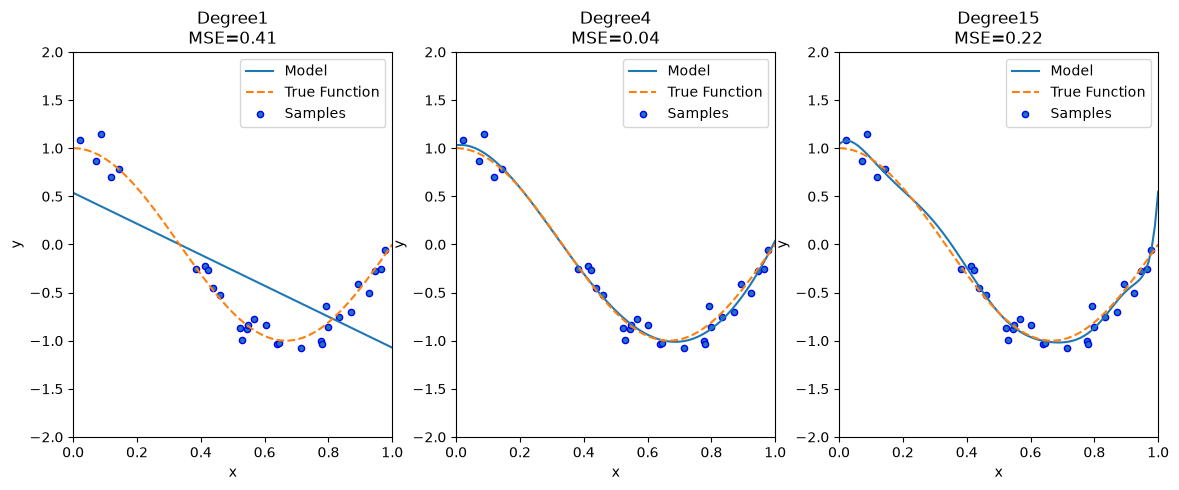

In [25]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i+ 1)
    polynomial_features = PolynomialFeatures(degree = degrees[i], include_bias = False)
    lr_reg = LinearRegression()
    X_poly = polynomial_features.fit_transform(X.reshape(-1, 1), y)
    lr_reg.fit(X_poly, y)
    scores = cross_val_score(lr_reg, X_poly, y, scoring = 'neg_mean_squared_error', cv = 10)
    coeff = lr_reg.coef_
    print(f'\nDegree{degrees[i]} 회귀계수는\n{np.round(coeff, 2)}\n입니다.')
    print(f'MSE는{-1 * np.mean(scores)}입니다.')
    X_test= np.linspace(0, 1, 100).reshape(-1, 1)
    X_test_poly= polynomial_features.transform(X_test)
    pred = lr_reg.predict(X_test_poly)
    plt.plot(X_test, pred, label = 'Model')
    plt.plot(X_test, true_fun(X_test), '--', label='True Function')
    plt.scatter(X, y, edgecolors='b', s = 20, label = 'Samples')
    plt.xlabel('x');plt.ylabel('y'); plt.xlim((0,1)); plt.ylim((-2, 2)); plt.legend()
    plt.title(f'Degree{degrees[i]}\nMSE={-scores.mean():.2f}')
plt.show()

In [26]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
ridge = Ridge(alpha = 10)
neg_mse_scores= cross_val_score(ridge, X, y, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse= np.mean(rmse_scores)
print('5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print('5 folds의 개별 RMSE scores : ', np.round(rmse_scores, 3))
print('5 folds의 평균 RMSE : {0:.3f} '.format(avg_rmse))

5 folds의 개별 Negative MSE scores:  [-4540.477 -5430.505 -5284.404 -4364.15  -5463.355]
5 folds의 개별 RMSE scores :  [67.383 73.692 72.694 66.062 73.915]
5 folds의 평균 RMSE : 70.749 


In [27]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X, y, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print('5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print('5 folds의 개별 RMSE scores : ', np.round(rmse_scores,3))
print('5 folds의 평균 RMSE : {0:.3f} '.format(avg_rmse)) 

5 folds의 개별 Negative MSE scores:  [-4540.477 -5430.505 -5284.404 -4364.15  -5463.355]
5 folds의 개별 RMSE scores :  [67.383 73.692 72.694 66.062 73.915]
5 folds의 평균 RMSE : 70.749 


In [28]:
from sklearn.linear_model import Ridge

# 바로 위 셀(다항회귀 degree 비교)에서 X_train/X_test가 다른 실험용 데이터로 덮어써졌기 때문에,
# diabetes 데이터로 train/test를 다시 만들어야 한다.
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)

ridge = Ridge()
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

mean_squared_error(y_test, pred)

3456.8959967710252

In [29]:
# Ridge
# - L2 규제를 사용한다.
# - 회귀 계수를 0에 가깝게 줄이긴 하나 0으로는 만들지 않는다.
# - 독립변수의 중요도를 낮춘다.
# - 다중공선성 문제가 있을 때 사용한다.

# Lasso
# - L1 규제를 사용한다.
# - 회귀 계수를 0으로 만들어버림
# - 독립변수를 선택한다.
# - 모델의 경량화

# ElasticNet
# - Ridge와 Lasso의 특징을 합쳐놓은 모델


#### 경사 하강법

In [35]:
# 확률적 경사 하강법(SGD) 실습
from sklearn.linear_model import SGDRegressor

alphas = [0, 0.01, 0.1, 1, 10]
for alpha in alphas:
    sgd_reg = SGDRegressor(alpha = alpha, penalty= 'l2', max_iter=10000)       # shuffle=True로 데이터를 섞는 기능도 가지고 있음
    neg_mse_scores = cross_val_score(sgd_reg, X, y, scoring = "neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print(f'alpha {alpha} 일 때 5 folds의 평균 RMSE : {avg_rmse:.3f}')

alpha 0 일 때 5 folds의 평균 RMSE : 54.919
alpha 0.01 일 때 5 folds의 평균 RMSE : 65.718
alpha 0.1 일 때 5 folds의 평균 RMSE : 75.145
alpha 1 일 때 5 folds의 평균 RMSE : 77.007
alpha 10 일 때 5 folds의 평균 RMSE : 77.243


In [ ]:
from sklearn.linear_model import SGDRegressor

# SGDRegressor: 전체 데이터를 한번에 쓰는 게 아니라, 데이터를 조금씩(샘플 단위로) 보면서
# 예측값과 실제값의 오차를 줄이는 방향으로 회귀 계수를 반복적으로 조금씩 업데이트하는 모델
# (확률적 경사 하강법 = Stochastic Gradient Descent)

# sgd = SGDRegressor() 이렇게 실행하면 경고메시지가 뜸
# max_iter = 10000처럼 큰 값을 넣으면
# ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
#  warnings.warn(
# 과 같은 경고가 뜨지 않는다.
# -> 기본 max_iter(반복 횟수)가 너무 적어서 계수가 최적값에 도달(수렴)하기 전에 학습이 멈춰서 뜨는 경고이므로,
#    반복 횟수를 충분히 늘려주면 끝까지 수렴할 시간을 줘서 경고가 사라진다.
sgd = SGDRegressor(max_iter = 10000)

# 바로 위 Ridge 셀에서 만든 X_train, y_train, X_test, y_test(디아벳 데이터 train/test)를 그대로 재사용
sgd.fit(X_train, y_train)
pred = sgd.predict(X_test)

mean_squared_error(y_test, pred)

2950.906472258275

In [38]:
# 회귀 트리 실습
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
diabetes_df= pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
diabetes_df['target'] = diabetes.target
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]


In [39]:
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
mse_scores = cross_val_score(rf_reg, X, y, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * mse_scores)
avg_rmse = np.mean(rmse_scores)
print(' 5 교차 검증의 개별 Negative MSE scores: ',  np.round(mse_scores, 2))
print(' 5 교차 검증의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(f' 5 교차 검증의 평균 RMSE : {avg_rmse:.3f} ')

 5 교차 검증의 개별 Negative MSE scores:  [-2994.11 -3112.26 -3547.44 -3272.69 -3709.92]
 5 교차 검증의 개별 RMSE scores :  [54.72 55.79 59.56 57.21 60.91]
 5 교차 검증의 평균 RMSE : 57.637 


In [40]:
def get_model_cv_prediction(model, X, y):
    neg_mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv = 5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print('##### ',model.__class__.__name__ , ' #####')
    print(' 5 교차 검증의 평균 RMSE : {0:.3f} '.format(avg_rmse))

In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000)
xgb_reg = XGBRegressor(random_state=0, n_estimators=1000)

In [43]:
models = [dt_reg, rf_reg, gb_reg, xgb_reg]
for model in models:  
    get_model_cv_prediction(model, X, y)

#####  DecisionTreeRegressor  #####
 5 교차 검증의 평균 RMSE : 64.320 
#####  RandomForestRegressor  #####
 5 교차 검증의 평균 RMSE : 57.637 
#####  GradientBoostingRegressor  #####
 5 교차 검증의 평균 RMSE : 65.543 
#####  XGBRegressor  #####
 5 교차 검증의 평균 RMSE : 63.161 


### 머신러닝 예측 실습 순서  
1. 데이터 정의  
    - 수집방법, 컬럼종류  
2. 데이터 준비
3. 데이터 전처리
4. 데이터 분석
5. 머신러닝 학습/예측/평가
6. 머신러닝 성능향상 방법 찾기